<a href="https://colab.research.google.com/github/muraleee/collab-stuff/blob/main/LangGraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# !pip install -qU --force-reinstall langchain-core
!pip install -qU  langchain-core langchain langchain-openai langchain-community langchain-anthropic

##Get Keys

In [8]:
import os
import getpass

from google.colab import userdata



def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = userdata.get(var)

_set_env("OPENAI_API_KEY")
_set_env("ANTHROPIC_API_KEY")
_set_env("TAVILY_API_KEY")

## How to use Langchain for Structured Output

In [ ]:
from pydantic import BaseModel, Field
from langchain.chat_models import init_chat_model

# 1. Define your schema
class ModelDocumentation(BaseModel):
    models: str = Field(description="Models section")
    basic_usage: str = Field(description="Basic Usage section")

# 2. Load your data
# Ensure 'course_example.md' exists in your directory
with open("./content.md", "r") as f:
    prompt = f.read()

# 3. Initialize the model
# Note: Ensure your OPENAI_API_KEY is set in your environment variables

llm = init_chat_model("claude-sonnet-4-5-20250929", model_provider="anthropic")
# 4. Bind the structured output
structured_llm = llm.with_structured_output(ModelDocumentation)

# 5. Invoke and print
response = structured_llm.invoke(prompt)



In [ ]:
from IPython.display import Markdown

Markdown(response.content)

## Using Langchain to call a model

In [ ]:
from langchain_core.messages import HumanMessage, SystemMessage

messages = [
    SystemMessage(content="You are a helpful assistant that can group text based on headings"),
    HumanMessage(content=prompt)
]

llm = init_chat_model("claude-sonnet-4-5-20250929", model_provider="anthropic")

response = llm.invoke(messages)
response

In [ ]:
from IPython.display import Markdown

Markdown(response.content)

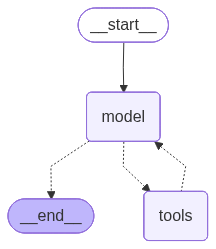

In [28]:
# Import relevant functionality
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent

# Create the agent
memory = MemorySaver()
# model = init_chat_model("gpt-5", model_provider="openai")
model = init_chat_model("claude-sonnet-4-5-20250929", model_provider="anthropic")
search = TavilySearchResults(max_results=2)
tools = [search]
# agent_executor = create_react_agent(model, tools)
agent_executor = create_agent(model, tools, checkpointer=memory)
agent_executor

In [17]:
query = """
How do I show that every positive integer can be expressed as the sum of four squares?
"""
config = {"configurable": {"thread_id": "murali_conversation_001"}}
messages = agent_executor.invoke({"messages": [("human", query)]}, config)
messages

{'messages': [HumanMessage(content='\nHow do I show that every positive integer can be expressed as the sum of four squares? \n', additional_kwargs={}, response_metadata={}, id='d2541d53-7d53-423f-b672-f903a0084cad'),
  AIMessage(content=[{'text': "I'll search for information about the four-square theorem and its proof.", 'type': 'text'}, {'id': 'toolu_013jSgTnWZYoQCmrcioNbok9', 'input': {'query': 'Lagrange four square theorem proof every positive integer sum of four squares'}, 'name': 'tavily_search_results_json', 'type': 'tool_use', 'caller': {'type': 'direct'}}], additional_kwargs={}, response_metadata={'id': 'msg_01A5y45EQWr2EKcUuVpFHqri', 'model': 'claude-sonnet-4-5-20250929', 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 620, 'output_tokens': 87, 'server_tool_use': None, 

In [18]:
import json

def format_langchain_messages(data):
    """
    Formats a list of LangChain message objects into a readable string.
    """
    messages = data.get('messages', [])
    formatted_output = []

    for msg in messages:
        # Determine the role (Human, AI, or Tool)
        msg_type = type(msg).__name__

        # 1. Handle Human Messages
        if "HumanMessage" in msg_type:
            formatted_output.append(f"--- USER ---\n{msg.content}\n")

        # 2. Handle AI Messages
        elif "AIMessage" in msg_type:
            # Check if there's text content or tool calls
            content = msg.content if msg.content else "[Initiating Tool Calls...]"
            formatted_output.append(f"--- AI ---\n{content}")

            # If the AI called tools, list them
            if hasattr(msg, 'tool_calls') and msg.tool_calls:
                for tool in msg.tool_calls:
                    formatted_output.append(f"  > CALLING TOOL: {tool['name']}")
                    formatted_output.append(f"    QUERY: {tool['args'].get('query')}")
            formatted_output.append("") # Spacer

        # 3. Handle Tool Responses
        elif "ToolMessage" in msg_type:
            formatted_output.append(f"--- TOOL RESPONSE ({msg.name}) ---")
            try:
                # Attempt to parse and pretty-print the JSON content
                parsed_content = json.loads(msg.content)
                # Just showing titles/snippets for brevity
                for i, item in enumerate(parsed_content[:2], 1): # Limit to first 2 results
                    title = item.get('title', 'No Title')
                    formatted_output.append(f"  {i}. {title}")
            except:
                formatted_output.append(f"  [Raw Content]: {msg.content[:100]}...")
            formatted_output.append("") # Spacer

    return "\n".join(formatted_output)

# --- EXECUTION ---
# Assuming 'your_data' is the dictionary you provided:
print(format_langchain_messages(messages))

--- USER ---

How do I show that every positive integer can be expressed as the sum of four squares? 


--- AI ---
[{'text': "I'll search for information about the four-square theorem and its proof.", 'type': 'text'}, {'id': 'toolu_013jSgTnWZYoQCmrcioNbok9', 'input': {'query': 'Lagrange four square theorem proof every positive integer sum of four squares'}, 'name': 'tavily_search_results_json', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
  > CALLING TOOL: tavily_search_results_json
    QUERY: Lagrange four square theorem proof every positive integer sum of four squares

--- TOOL RESPONSE (tavily_search_results_json) ---
  1. [PDF] Quarternions and the four square theorem
  2. [PDF] Every Positive Integer is the Sum of Four Squares! (and other ...

--- AI ---
The **Four-Square Theorem** (also called Lagrange's Four-Square Theorem) states that every positive integer can be expressed as the sum of four integer squares. Here's an outline of how to prove it:

## Key Components of the

In [24]:
!pip install -qU langchain-experimental

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.1/210.1 kB 4.7 MB/s eta 0:00:00


In [ ]:
from langchain_experimental.tools import PythonREPLTool
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver

# 1. Initialize Tools
search_tool = TavilySearchResults(max_results=3)
python_tool = PythonREPLTool() # Allows the agent to write and run Python code

tools = [search_tool, python_tool]

# 2. Initialize Agent with Memory
memory = MemorySaver()
agent_executor = create_react_agent(model, tools, checkpointer=memory)

# 3. Test it with a complex request
config = {"configurable": {"thread_id": "math_researcher_01"}}

query = "Find the current stock price of NVIDIA and calculate what 15 shares would be worth if the price increased by 12.5%."

for event in agent_executor.stream({"messages": [("user", query)]}, config):
    for node, values in event.items():
        print(f"\n--- Node: {node} ---")
        # Just print the last message content
        print(values["messages"][-1].content)

In [ ]:
from langchain_experimental.tools import PythonREPLTool
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver

# 1. Initialize Tools
search_tool = TavilySearchResults(max_results=3)
python_tool = PythonREPLTool() # Allows the agent to write and run Python code

tools = [search_tool, python_tool]

# 2. Initialize Agent with Memory
memory = MemorySaver()
agent_executor = create_react_agent(model, tools, checkpointer=memory)

# 3. Test it with a complex request
config = {"configurable": {"thread_id": "math_researcher_01"}}

query = "Find the current stock price of NVIDIA and calculate what 15 shares would be worth if the price increased by 12.5%."

for event in agent_executor.stream({"messages": [("user", query)]}, config):
    for node, values in event.items():
        print(f"\n--- Node: {node} ---")
        # Just print the last message content
        print(values["messages"][-1].content)